# Data Pre-Processing
# Import Packages and CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"D:\New folder (2)\End-to-End-Machine-Learning-Project-Implementation\notebooks\data.csv")
# Print shape of dataset
print(df.shape)

(2614, 21)


# Data Cleaning
# Handling Missing values
# Handling Duplicates
# Check data type
# Understand the dataset

In [2]:
##these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

Who or what influences your decision to move abroad? (Multiple options can be selected) 0.03826 % missing values
Do you think you will return to Bangladesh in the future after living abroad? 0.03826 % missing values
Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?   0.07651 % missing values


In [3]:
features_with_na

['Who or what influences your decision to move abroad? (Multiple options can be selected)',
 'Do you think you will return to Bangladesh in the future after living abroad?',
 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?  ']

# Fill missing values with mode (most frequent value)

In [4]:
for feature in features_with_na:
    mode_value = df[feature].mode()[0]
    df[feature].fillna(mode_value, inplace=True)

# Verify no missing values left

In [5]:
print("\nAfter filling missing values:")
print(df.isnull().sum())


After filling missing values:
What is your age?                                                                                                                                        0
What is your gender?                                                                                                                                     0
What is your occupation?                                                                                                                                 0
Does any member of your family or a close acquaintance live abroad?                                                                                      0
Have you decided to move abroad?                                                                                                                         0
How long do you plan to stay abroad?                                                                                                                     0
Are you aware of any specific migration

### Other Data Cleaning steps
# Handling Duplicates

In [6]:
df.duplicated().sum()

0

### No Duplicates in the dataset
### Remove case_id from the dataset as it cannot used in Model Training

# i have no case id in  my dataset

# Feature Engineering
# Feature Extraction

In [10]:

df.head()

,What is your age?,What is your gender?,What is your occupation?,Does any member of your family or a close acquaintance live abroad?,Have you decided to move abroad?,How long do you plan to stay abroad?,Are you aware of any specific migration programs or scholarships available for students or workers abroad?,What role do social media and online success stories play in influencing your decision to move abroad?,Who or what influences your decision to move abroad? (Multiple options can be selected),Which countries are you most interested in moving to?,How much psychological stress or anxiety have you experienced while considering moving abroad?,What is your primary goal for considering moving abroad? (Multiple options can be selected),What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected),How do you cope with the stress of planning to move abroad?,Do you think migration trends have increased among Bangladeshi youth in the last 5 years?,What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected),Do you think you will return to Bangladesh in the future after living abroad?,Do you think your decision to move abroad will impact your family or community in Bangladesh?,Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?,Do you feel a sense of responsibility towards your family while planning to move abroad?,"How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely)."
0,31-40,Male,Unemployed,No,Not sure yet,Permanently,Yes,No role at all,Personal research and aspirations;Career mento...,USA,Often,Other;Desire for independence;Economic opportu...,Visa or immigration concerns;Cultural shock;Se...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Not sure,Positive impact,No,Yes,1
1,18-24,Male,Student,Yes,Yes,3-5 years,Yes,No role at all,Family pressure or support;Personal research a...,USA,Sometimes,Better living standards;Higher education;Desir...,Job uncertainty;Other;Visa or immigration conc...,Hobbies or physical exercise,I’m not sure,Other;Financial issues;Family pressure or support,Not sure,Negative impact,Not Sure,Yes,5
2,31-40,Female,Other,Yes,No,Permanently,Maybe,A significant role,Personal research and aspirations;Friends or p...,UK,Often,Political stability;Economic opportunities;Hig...,Social acceptance;Visa or immigration concerns...,Joining online forums,No change,Educational qualification;Job information or e...,Yes,No impact,Not Sure,Maybe,5
3,25-30,Male,Employed,Yes,No,Permanently,Yes,A significant role,Social media and online success stories;Other;...,"Europe (e.g., Germany, Sweden)",Always,Economic opportunities;Political stability;Des...,Other;Cultural shock;Visa or immigration concerns,Talking to family and friends,I’m not sure,Other;Financial issues;Job information or expe...,Yes,Positive impact,Not Sure,No,3
4,40 or above,Male,Self-employed,Yes,Yes,3-5 years,No,A significant role,Other;Personal research and aspirations;Friend...,Canada,Often,Better job opportunities;Better living standar...,Visa or immigration concerns;Other;Separation ...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Yes,Negative impact,Not Sure,No,2


# 1. Column clean

In [19]:
df.columns = df.columns.str.strip()

# 2. Age → numeric

In [20]:
df['What is your age?'] = pd.to_numeric(df['What is your age?'], errors='coerce')

# 3.Age → Group (Derived Feature)

In [21]:
df['age_group'] = pd.cut(
    df['What is your age?'],
    bins=[0,18,25,35,50,100],
    labels=['Teen','Youth','Young Adult','Adult','Senior']
)

# 4.Yes/No → Binary (0/1)

In [22]:
yes_no_cols = [
    'Does any member of your family or a close acquaintance live abroad?',
    'Have you decided to move abroad?',
    'Are you aware of any specific migration programs or scholarships available for students or workers abroad?',
    'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?',
    'Do you think you will return to Bangladesh in the future after living abroad?',
    'Do you think your decision to move abroad will impact your family or community in Bangladesh?',
    'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?',
    'Do you feel a sense of responsibility towards your family while planning to move abroad?'
]

for col in yes_no_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

# 5 Target Variable creat

In [23]:
df['target'] = df['Have you decided to move abroad?']

# 6: Multiple Options → Count Feature (Main Extraction)

In [24]:
multi_cols = [
    'Who or what influences your decision to move abroad? (Multiple options can be selected)',
    'What is your primary goal for considering moving abroad? (Multiple options can be selected)',
    'What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected)',
    'What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected)'
]

for col in multi_cols:
    df[col + '_count'] = df[col].apply(lambda x: len(str(x).split(',')))

# 7: Country → Count Feature

In [25]:
df['country_count'] = df['Which countries are you most interested in moving to?']\
                        .apply(lambda x: len(str(x).split(',')))

# 8: Recommendation Score → Numeric

In [26]:
df['recommend_score'] = pd.to_numeric(
    df['How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).'],
    errors='coerce'
)

# 9: Stress → Numeric Encode

In [27]:
df['stress_score'] = pd.factorize(
    df['How much psychological stress or anxiety have you experienced while considering moving abroad?']
)[0]

# 10: Final Check

In [28]:
df.head()

,What is your age?,What is your gender?,What is your occupation?,Does any member of your family or a close acquaintance live abroad?,Have you decided to move abroad?,How long do you plan to stay abroad?,Are you aware of any specific migration programs or scholarships available for students or workers abroad?,What role do social media and online success stories play in influencing your decision to move abroad?,Who or what influences your decision to move abroad? (Multiple options can be selected),Which countries are you most interested in moving to?,How much psychological stress or anxiety have you experienced while considering moving abroad?,What is your primary goal for considering moving abroad? (Multiple options can be selected),What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected),How do you cope with the stress of planning to move abroad?,Do you think migration trends have increased among Bangladeshi youth in the last 5 years?,What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected),Do you think you will return to Bangladesh in the future after living abroad?,Do you think your decision to move abroad will impact your family or community in Bangladesh?,Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?,Do you feel a sense of responsibility towards your family while planning to move abroad?,"How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).",Who or what influences your decision to move abroad? (Multiple options can be selected)_count,What is your primary goal for considering moving abroad? (Multiple options can be selected)_count,What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected)_count,What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected)_count,stress_level,preferred_country_count,recommend_score,age_group,target,country_count,stress_score
0,NaN,Male,Unemployed,0,NaN,Permanently,1.0,No role at all,Personal research and aspirations;Career mento...,USA,Often,Other;Desire for independence;Economic opportu...,Visa or immigration concerns;Cultural shock;Se...,Hobbies or physical exercise,NaN,Job information or experience;Other;All countr...,NaN,NaN,0.0,1.0,1,1,1,1,1,Often,1,1,NaN,NaN,1,0
1,NaN,Male,Student,1,1.0,3-5 years,1.0,No role at all,Family pressure or support;Personal research a...,USA,Sometimes,Better living standards;Higher education;Desir...,Job uncertainty;Other;Visa or immigration conc...,Hobbies or physical exercise,NaN,Other;Financial issues;Family pressure or support,NaN,NaN,NaN,1.0,5,1,1,1,1,Sometimes,1,5,NaN,1.0,1,1
2,NaN,Female,Other,1,0.0,Permanently,NaN,A significant role,Personal research and aspirations;Friends or p...,UK,Often,Political stability;Economic opportunities;Hig...,Social acceptance;Visa or immigration concerns...,Joining online forums,NaN,Educational qualification;Job information or e...,1.0,NaN,NaN,NaN,5,1,1,1,1,Often,1,5,NaN,0.0,1,0
3,NaN,Male,Employed,1,0.0,Permanently,1.0,A significant role,Social media and online success stories;Other;...,"Europe (e.g., Germany, Sweden)",Always,Economic opportunities;Political stability;Des...,Other;Cultural shock;Visa or immigration concerns,Talking to family and friends,NaN,Other;Financial issues;Job information or expe...,1.0,NaN,NaN,0.0,3,1,1,1,1,Always,3,3,NaN,0.0,3,2
4,NaN,Male,Self-employed,1,1.0,3-5 years,0.0,A significant role,Other;Personal research and aspirations;Friend...,Canada,Often,Better job opportunities;Better living standar...,Visa or immigration concerns;Other;Separation ...,Hobbies or physical exercise,NaN,Job information or experience;Other;All countr...,1.0,NaN,NaN,0.0,2,1,1,1,1,Often,1,2,NaN,1.0,1,0


In [34]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        
        try:
            # Try numeric fill
            df[col] = pd.to_numeric(df[col], errors='ignore')
            
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode()
                if not mode_val.empty:
                    df[col] = df[col].fillna(mode_val[0])
                else:
                    df[col] = df[col].fillna('Unknown')
        
        except Exception as e:
            # fallback (never crash)
            df[col] = df[col].fillna('Unknown')

In [35]:
df.isnull().sum()

What is your age?                                                                                                                                           0
What is your gender?                                                                                                                                        0
What is your occupation?                                                                                                                                    0
Does any member of your family or a close acquaintance live abroad?                                                                                         0
Have you decided to move abroad?                                                                                                                            0
How long do you plan to stay abroad?                                                                                                                        0
Are you aware of any specific migration programs or 

সব missing value smart ভাবে fill করা হয়েছে:

number → median
text → mode
problem হলে → "Unknown"

# Type of Features
# 1:Numeric Features

In [36]:
num_features = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]

print("Num of Numerical Features:", len(num_features))
print(num_features)

Num of Numerical Features: 18
['Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?', 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?', 'Do you think you will return to Bangladesh in the future after living abroad?', 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?', 'Do you feel a sense of responsibility towards your family while planning to move abroad?', 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count', 'What kind of psychologica

# 2: Categorical Features

In [37]:
cat_features = [col for col in df.columns if df[col].dtype == 'object']

print("Num of Categorical Features:", len(cat_features))
print(cat_features)

Num of Categorical Features: 14
['What is your age?', 'What is your gender?', 'What is your occupation?', 'How long do you plan to stay abroad?', 'What role do social media and online success stories play in influencing your decision to move abroad?', 'Who or what influences your decision to move abroad? (Multiple options can be selected)', 'Which countries are you most interested in moving to?', 'How much psychological stress or anxiety have you experienced while considering moving abroad?', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)', 'What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected)', 'How do you cope with the stress of planning to move abroad?', 'What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected)', 'Do you think your decision to move abroad will impact your family or community in Bangladesh?', 'stress_level']


# 3: Discrete Features (numeric but low unique values)

In [38]:
discrete_features = [col for col in num_features if df[col].nunique() <= 25]

print("Num of Discrete Features:", len(discrete_features))
print(discrete_features)

Num of Discrete Features: 18
['Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?', 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?', 'Do you think you will return to Bangladesh in the future after living abroad?', 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?', 'Do you feel a sense of responsibility towards your family while planning to move abroad?', 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count', 'What kind of psychological

# 4: Continuous Features

In [39]:
continuous_features = [col for col in num_features if col not in discrete_features]

print("Num of Continuous Features:", len(continuous_features))
print(continuous_features)

Num of Continuous Features: 0
[]


# Split X and Y
# X (features) & y (target) split

In [58]:
# -------------------------------
# Step 1: clean target column
# -------------------------------
col = 'Have you decided to move abroad?'

# string clean (if any text exists)
df[col] = df[col].astype(str).str.strip().str.lower()

# replace possible values → numeric
df[col] = df[col].replace({
    'yes': 1, 'no': 0,
    '1': 1, '0': 0,
    '1.0': 1, '0.0': 0
})

# convert to numeric safely
df[col] = pd.to_numeric(df[col], errors='coerce')

# fill any remaining NaN with mode
df[col] = df[col].fillna(df[col].mode()[0])

# finally convert to int
df['target'] = df[col].astype(int)

# -------------------------------
# Step 2: Split X and y
# -------------------------------
X = df.drop('target', axis=1)
y = df['target']

# -------------------------------
# Step 3: Check (important)
# -------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\ny sample:")
print(y.head())

print("\ny dtype:", y.dtype)
print("\nTarget value counts:")
print(y.value_counts())

X shape: (2614, 31)
y shape: (2614,)

y sample:
0    0
1    1
2    0
3    0
4    1
Name: target, dtype: int32

y dtype: int32

Target value counts:
target
0    1793
1     821
Name: count, dtype: int64


# Feature Transformation
# 1: numeric features select

In [59]:
num_features = [
    'What is your age?',
    'recommend_score',
    'stress_score',
    'Who or what influences your decision to move abroad? (Multiple options can be selected)_count',
    'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count',
    'What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected)_count',
    'What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected)_count',
    'country_count'
]

# 2: Distribution plot (Before Scaling)

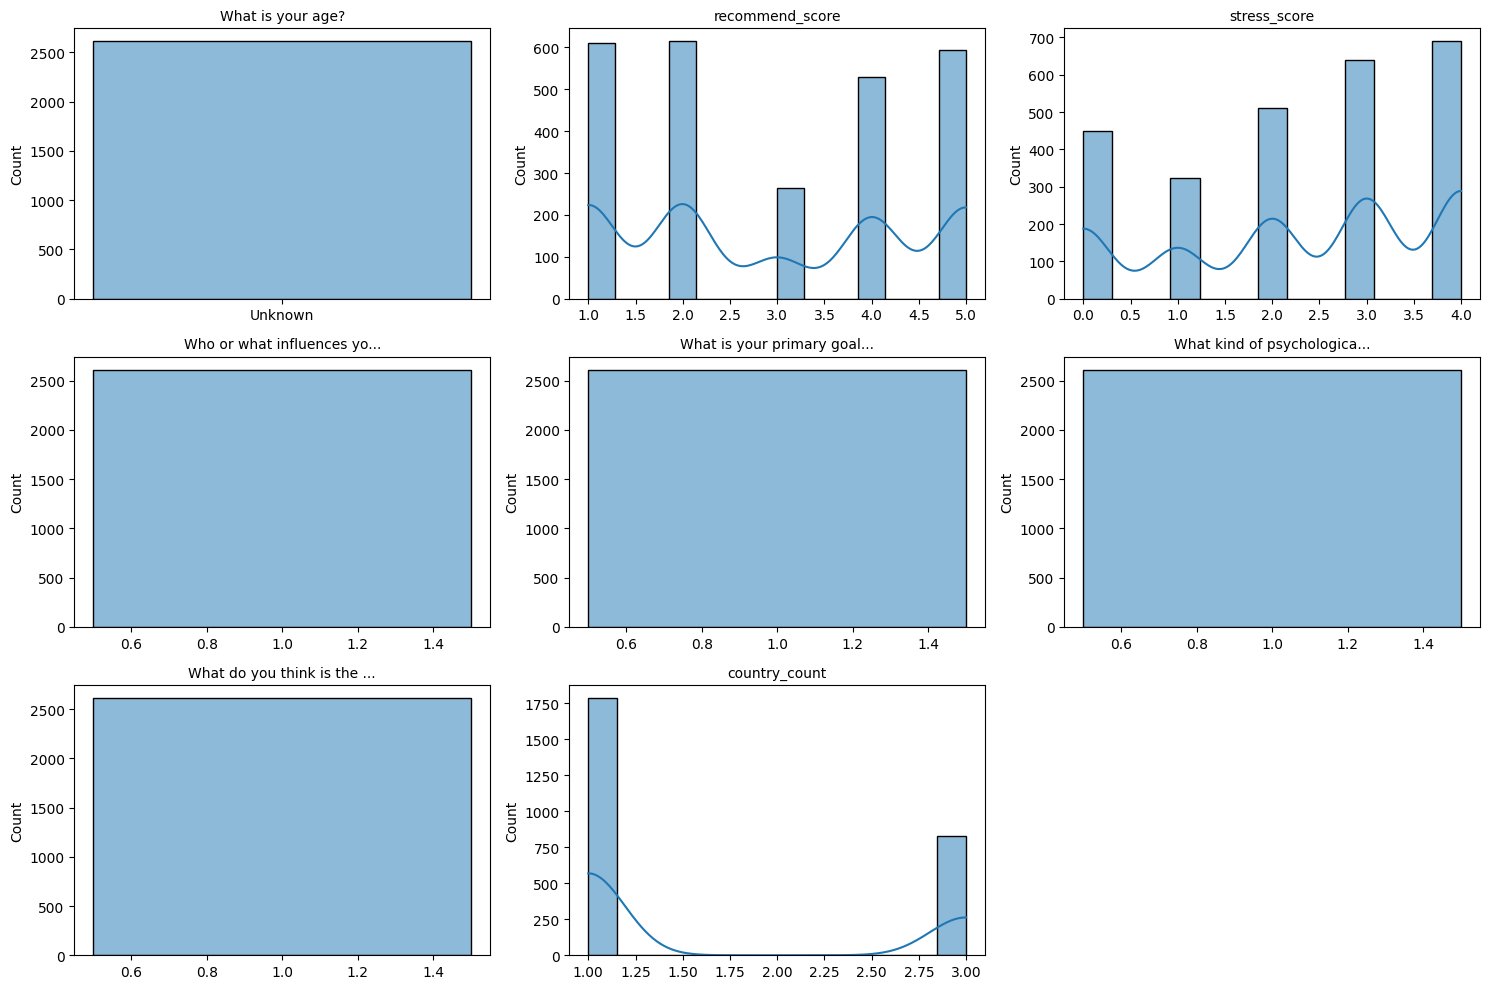

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    
    sns.histplot(X[col], kde=True)
    
    # short title (important)
    short_name = col[:25] + "..." if len(col) > 25 else col
    plt.title(short_name, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [64]:
!pip install scikit-learn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 5.6 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.3 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.3 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.3 MB 1.8 MB/s eta 0:00:05
   --------- ------------------------------ 2.1/9.3 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.7 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.3 MB 1.6 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.3 MB 1.6 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.3 MB 1.6 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.3 MB 1.6 MB/s eta 0:00:04
   ------------------ ----

# 3: Scaling (StandardScaler)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[num_features] = scaler.fit_transform(X[num_features])

# 4 Distribution After Scaling

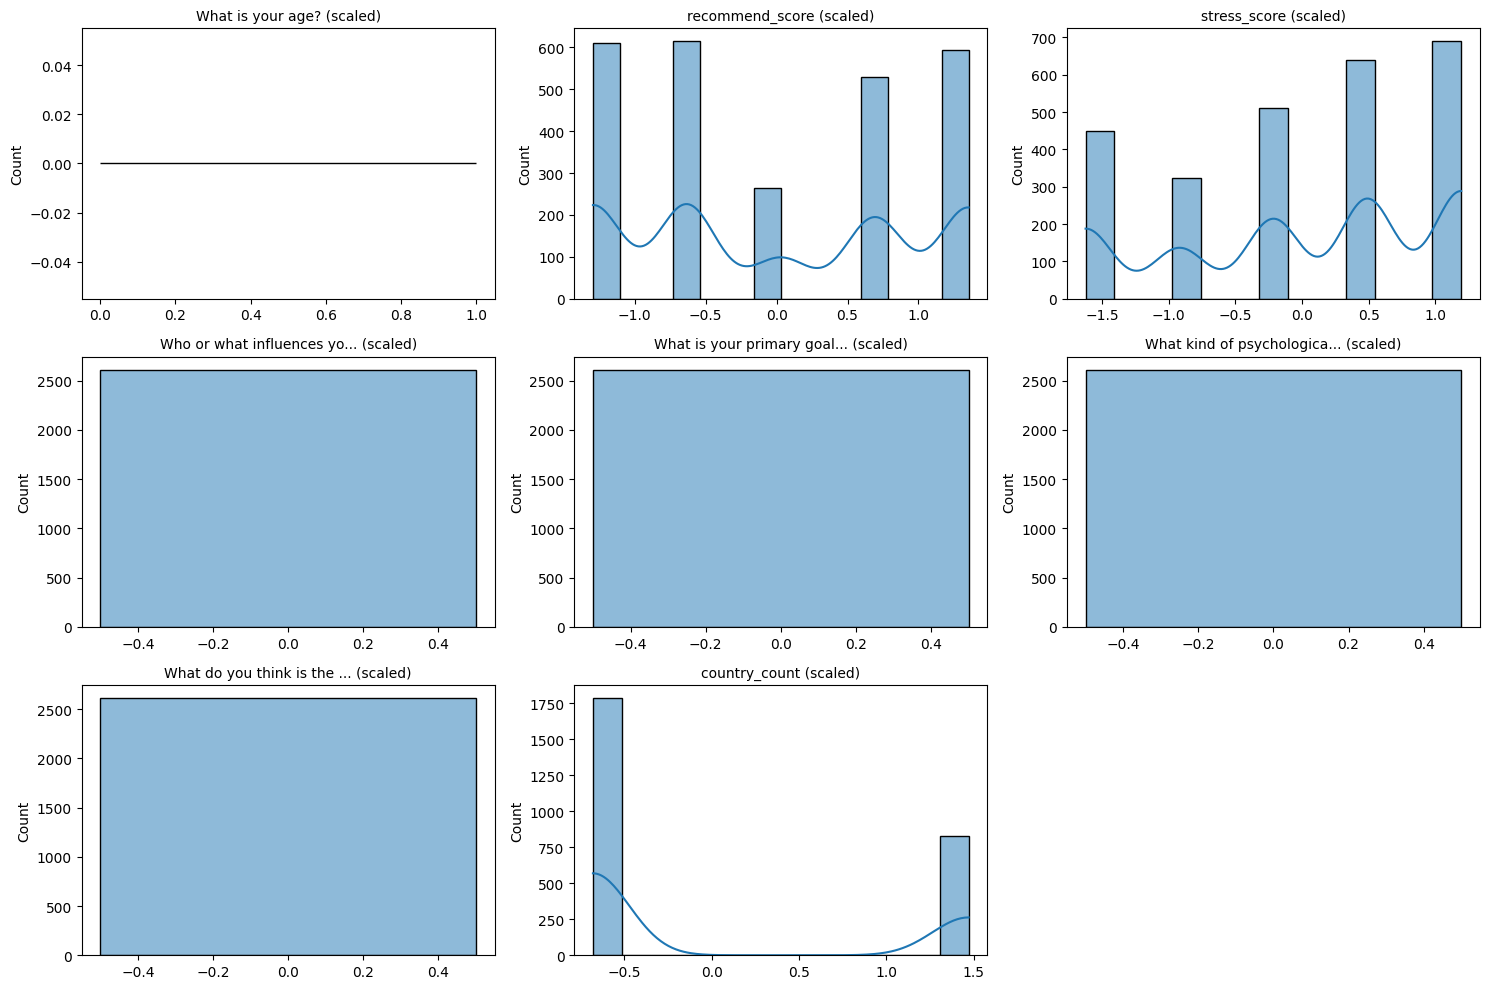

In [69]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    
    sns.histplot(X[col], kde=True)
    
    short_name = col[:25] + "..." if len(col) > 25 else col
    plt.title(short_name + " (scaled)", fontsize=10)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

# clean version

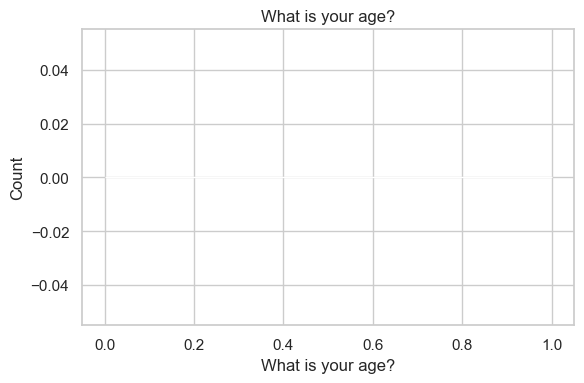

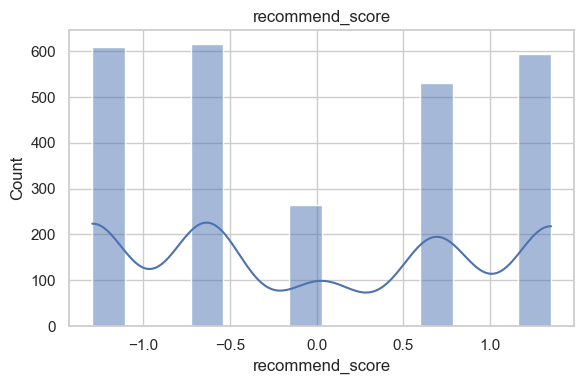

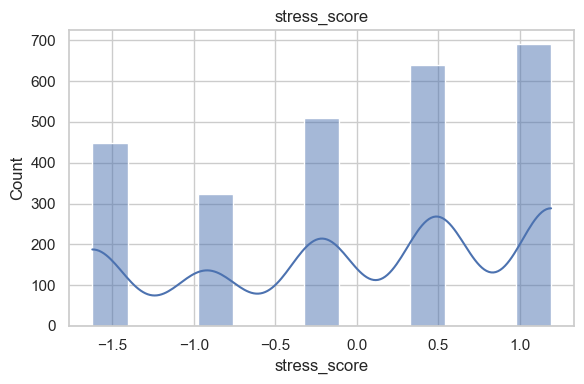

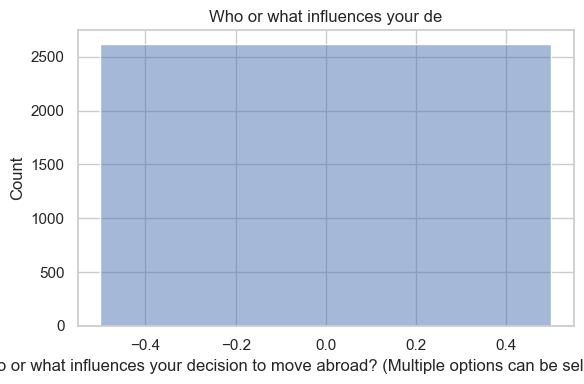

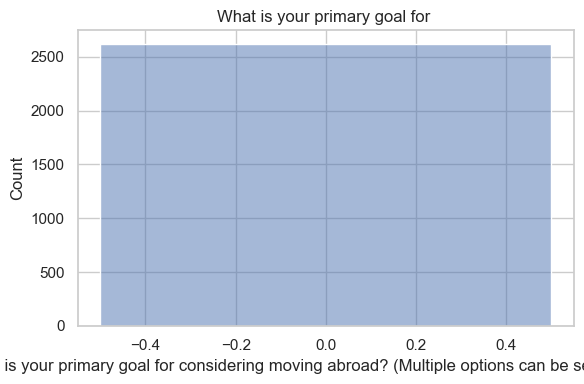

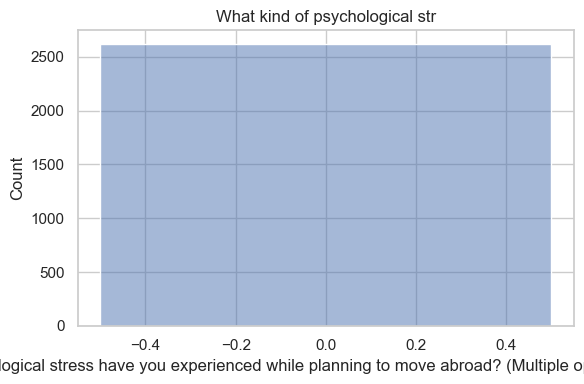

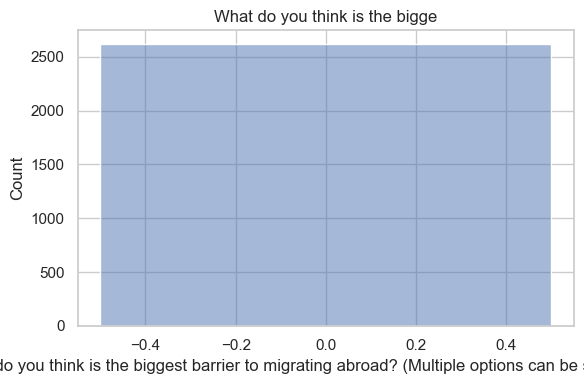

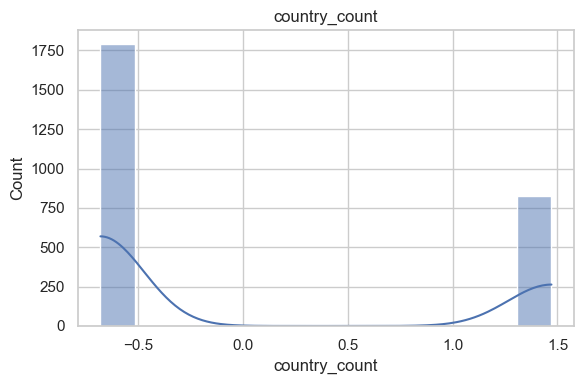

In [70]:
sns.set(style="whitegrid")

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(X[col], kde=True)
    plt.title(col[:30])
    plt.tight_layout()
    plt.show()

# Skewness step-by-step

# 1: Numeric features

In [73]:
import pandas as pd

num_features = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]

print("Numeric Features:")
print(num_features)

Numeric Features:
['What is your age?', 'Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?', 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?', 'Do you think you will return to Bangladesh in the future after living abroad?', 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?', 'Do you feel a sense of responsibility towards your family while planning to move abroad?', 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count', 'What kind of psy

# 2: Continuous-like features select (relaxed condition)

In [74]:
continuous_features = [col for col in num_features if X[col].nunique() > 2]

print("\nContinuous Features:")
print(continuous_features)


Continuous Features:
['How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'recommend_score', 'stress_score']


# 3: Skewness calculate

In [75]:
skewness = X[continuous_features].skew()

print("\nSkewness Values:")
print(skewness.sort_values(ascending=False))


Skewness Values:
How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).    0.064689
recommend_score                                                                                                                                          0.064689
stress_score                                                                                                                                            -0.355400
dtype: float64


# 4: Visualization

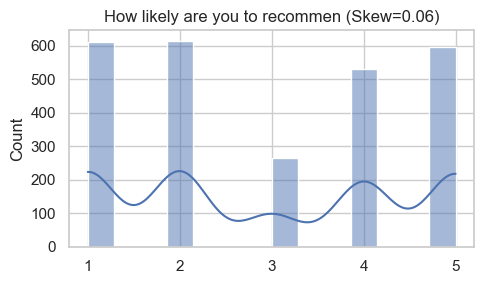

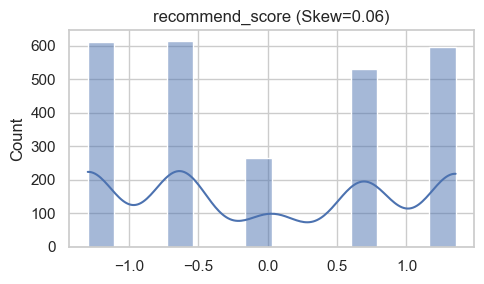

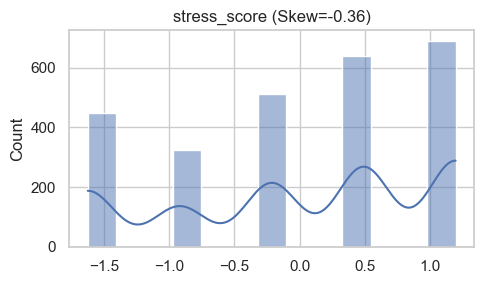

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col in continuous_features:
    plt.figure(figsize=(5,3))
    
    sns.histplot(X[col], kde=True)
    
    plt.title(f"{col[:30]} (Skew={X[col].skew():.2f})")
    plt.xlabel("")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()

# Short Summary

👉 Numeric detect →
👉 continuous filter →
👉 skew check →
👉 plot →


# Power Transformer for Skewness Reduction

# 1: Numeric features select

In [78]:
num_features = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]

print("Numeric Features:")
print(num_features)

Numeric Features:
['What is your age?', 'Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?', 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?', 'Do you think you will return to Bangladesh in the future after living abroad?', 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?', 'Do you feel a sense of responsibility towards your family while planning to move abroad?', 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count', 'What kind of psy

# 2:Transform feature select

In [79]:
transform_features = [col for col in num_features if X[col].nunique() > 2]

print("\nFeatures for Transformation:")
print(transform_features)


Features for Transformation:
['How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'recommend_score', 'stress_score']


# 3:Before Transformation (Skewness check)

In [80]:
print("\nSkewness BEFORE Transformation:\n")
print(X[transform_features].skew())


Skewness BEFORE Transformation:

How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).    0.064689
recommend_score                                                                                                                                          0.064689
stress_score                                                                                                                                            -0.355400
dtype: float64



Skewness AFTER Transformation:

How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).   -0.097935
recommend_score                                                                                                                                          0.020091
stress_score                                                                                                                                            -0.085889
dtype: float64


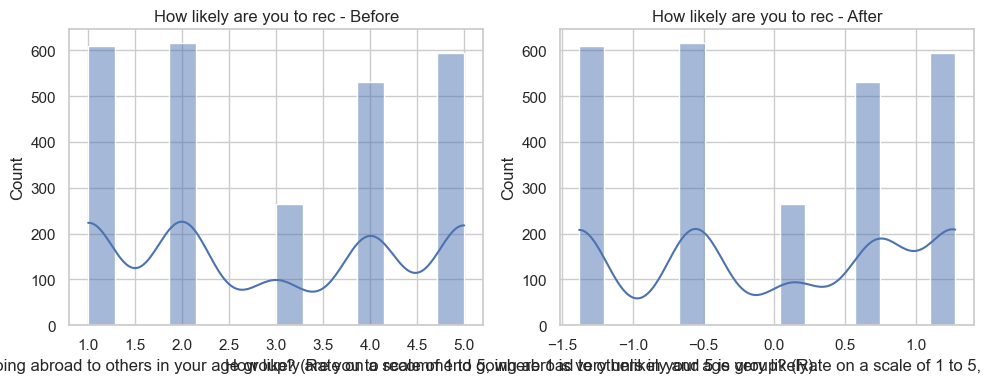

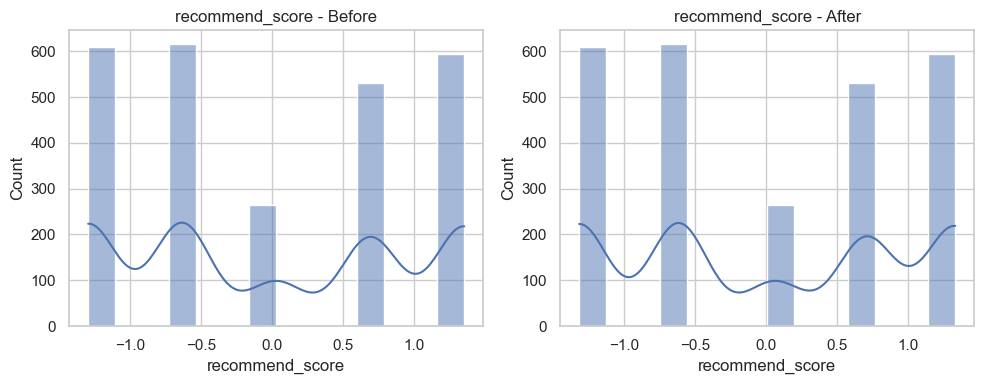

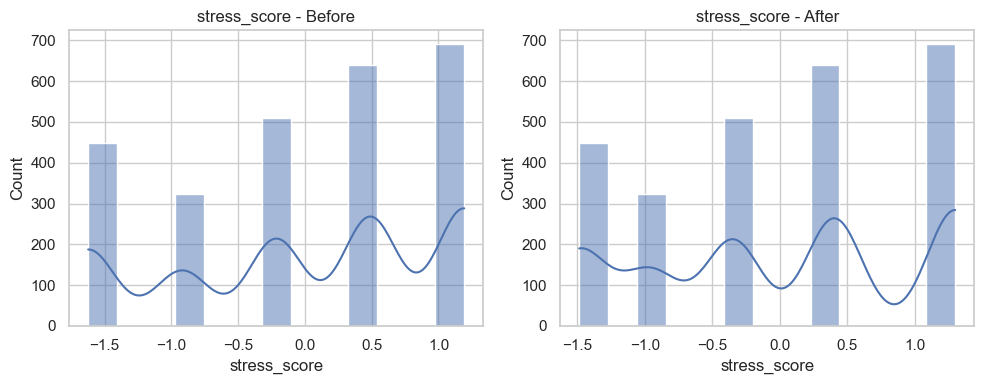

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# -------------------------------
# Step 1: Power Transformer
# -------------------------------
pt = PowerTransformer(method='yeo-johnson')

X_transformed = pt.fit_transform(X[transform_features])

# -------------------------------
# Step 2: Convert to DataFrame
# -------------------------------
X_transformed = pd.DataFrame(
    X_transformed, 
    columns=transform_features,
    index=X.index   # important (row match রাখার জন্য)
)

# -------------------------------
# Step 3: Skewness AFTER
# -------------------------------
print("\nSkewness AFTER Transformation:\n")
print(X_transformed.skew())

# -------------------------------
# Step 4: Visualization (Before vs After)
# -------------------------------
sns.set(style="whitegrid")

for col in transform_features:
    
    plt.figure(figsize=(10,4))
    
    # BEFORE
    plt.subplot(1,2,1)
    sns.histplot(X[col], kde=True)
    plt.title(f"{col[:25]} - Before")
    
    # AFTER
    plt.subplot(1,2,2)
    sns.histplot(X_transformed[col], kde=True)
    plt.title(f"{col[:25]} - After")
    
    plt.tight_layout()
    plt.show()

# CLEAN PLOT

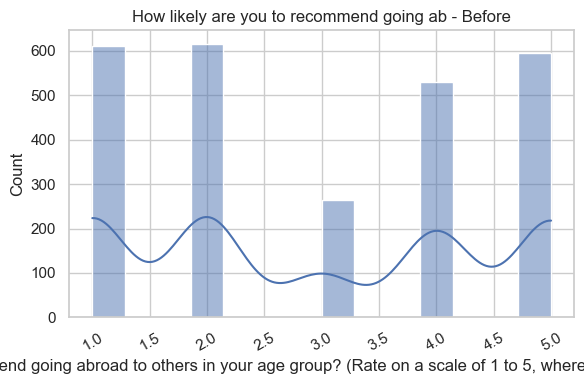

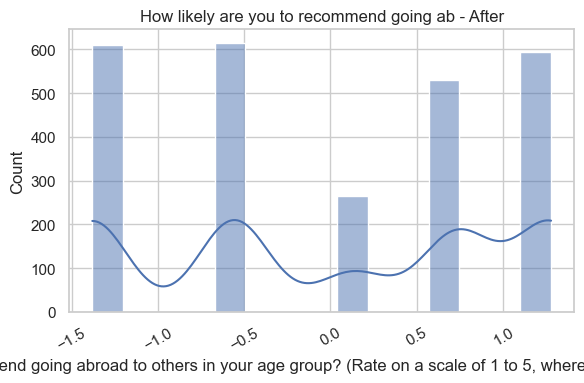

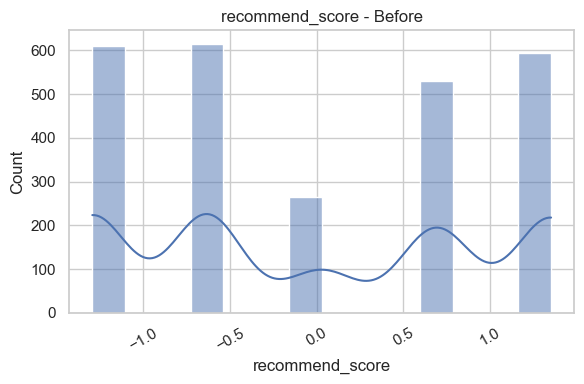

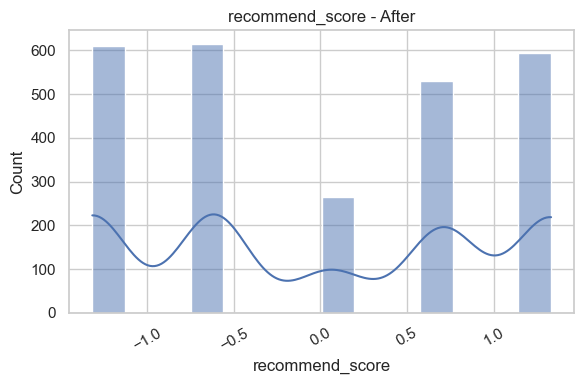

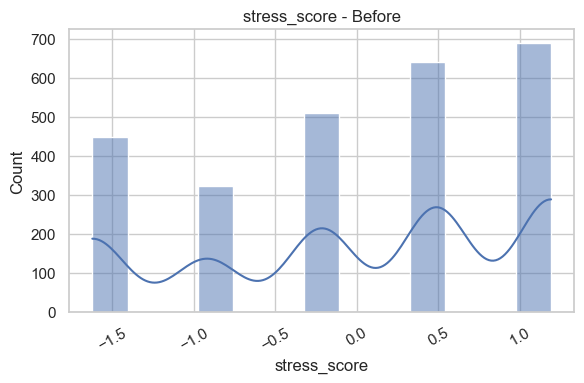

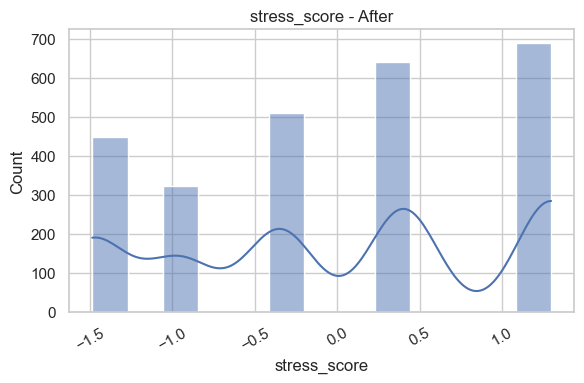

In [88]:
for col in transform_features:
    
    short_name = col[:40]
    
    plt.figure(figsize=(6,4))
    sns.histplot(X[col], kde=True)
    plt.title(f"{short_name} - Before")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(6,4))
    sns.histplot(X_transformed[col], kde=True)
    plt.title(f"{short_name} - After")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Selecting number features for preprocessing

In [89]:
# Selecting numeric features for preprocessing

import pandas as pd

num_features = [col for col in X.columns 
                if pd.api.types.is_numeric_dtype(X[col])]

print("Numeric Features:")
print(num_features)

Numeric Features:
['What is your age?', 'Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?', 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?', 'Do you think you will return to Bangladesh in the future after living abroad?', 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?', 'Do you feel a sense of responsibility towards your family while planning to move abroad?', 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).', 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count', 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count', 'What kind of psy

In [90]:
num_features

['What is your age?',
 'Does any member of your family or a close acquaintance live abroad?',
 'Have you decided to move abroad?',
 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?',
 'Do you think migration trends have increased among Bangladeshi youth in the last 5 years?',
 'Do you think you will return to Bangladesh in the future after living abroad?',
 'Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?',
 'Do you feel a sense of responsibility towards your family while planning to move abroad?',
 'How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).',
 'Who or what influences your decision to move abroad? (Multiple options can be selected)_count',
 'What is your primary goal for considering moving abroad? (Multiple options can be selected)_count',
 'What kind of psychologi

# Preprocessing using Column Transformer

In [97]:

import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Define X and y (IMPORTANT)
# -------------------------------
X = df.drop('target', axis=1)
y = df['target']

# -------------------------------
# Step 2: Column Groups
# -------------------------------

# OneHot Encoding (low unique categorical)
oh_columns = [
    'What is your gender?',
    'What is your occupation?',
    'How long do you plan to stay abroad?',
    'How do you cope with the stress of planning to move abroad?'
]

# Ordinal Encoding (ordered feature)
or_columns = [
    'How much psychological stress or anxiety have you experienced while considering moving abroad?'
]

# Numeric features (auto detect)
num_features = [col for col in X.columns 
                if pd.api.types.is_numeric_dtype(X[col])]

# -------------------------------
# Step 3: Transformers
# -------------------------------

numeric_transformer = StandardScaler()

oh_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ordinal_encoder = OrdinalEncoder()

# -------------------------------
# Step 4: Column Transformer
# -------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", oh_transformer, oh_columns),
        ("ordinal", ordinal_encoder, or_columns),
        ("num", numeric_transformer, num_features)
    ],
    remainder='drop'
)

# -------------------------------
# Step 5: Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 6: Apply Preprocessing
# -------------------------------

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# -------------------------------
# Step 7: Check Output
# -------------------------------

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (2091, 35)
Test shape: (523, 35)


# এই code কী নিশ্চিত করে?

✔ DataFrame ঠিকভাবে ব্যবহার
✔ Encoding + Scaling একসাথে
✔ No column mismatch
✔ No numpy error
✔ Train/Test properly separated

# Classification

In [101]:
import numpy as np

print("NaN count:", np.isnan(X_train_processed).sum())

NaN count: 2091


In [112]:
print("NaN after fix:", np.isnan(X_train_processed).sum())

NaN after fix: 0


In [144]:
# 1. split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. preprocess
# 3. SMOTE only on X_train

In [152]:
from sklearn.model_selection import train_test_split

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res   # balance ঠিক রাখার জন্য
)

print(X_train.shape, X_test.shape)

(2173, 35) (544, 35)


# Nan thake  smote kaj kore na

# Train Test Split

In [145]:
from sklearn.model_selection import  train_test_split
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((2173, 35), (544, 35))

In [154]:
# Classification Models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Advanced Models
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [155]:
def evaluate_clf(true, predicted):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
    
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    roc_auc = roc_auc_score(true, predicted)
    
    return acc, f1, precision, recall, roc_auc

In [156]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost Classifier": CatBoostClassifier(verbose=False),
    "Support Vector Classifier": SVC(probability=True),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [157]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    '''
    Already split করা data (X_train, X_test) use করে model evaluate করবে
    '''

    import pandas as pd

    models_list = []
    accuracy_list = []
    auc_list = []

    for name, model in models.items():
        
        # Train model
        model.fit(X_train, y_train)

        # Prediction
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training performance
        train_acc, train_f1, train_prec, train_rec, train_auc = evaluate_clf(y_train, y_train_pred)

        # Test performance
        test_acc, test_f1, test_prec, test_rec, test_auc = evaluate_clf(y_test, y_test_pred)

        print(name)
        models_list.append(name)

        print('🔹 Training Performance')
        print(f"Accuracy: {train_acc:.4f}")
        print(f"F1-score: {train_f1:.4f}")
        print(f"Precision: {train_prec:.4f}")
        print(f"Recall: {train_rec:.4f}")
        print(f"ROC-AUC: {train_auc:.4f}")

        print('-----------------------------')

        print('🔹 Test Performance')
        print(f"Accuracy: {test_acc:.4f}")
        print(f"F1-score: {test_f1:.4f}")
        print(f"Precision: {test_prec:.4f}")
        print(f"Recall: {test_rec:.4f}")
        print(f"ROC-AUC: {test_auc:.4f}")

        accuracy_list.append(test_acc)
        auc_list.append(test_auc)

        print("="*40, "\n")

    # Final report
    report = pd.DataFrame({
        "Model": models_list,
        "Accuracy": accuracy_list,
        "ROC-AUC": auc_list
    }).sort_values(by="Accuracy", ascending=False)

    return report

In [158]:
report = evaluate_models(X_train, X_test, y_train, y_test, models)
print(report)

Random Forest
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000

Decision Tree
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000

Gradient Boosting
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000

Logistic Regression
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.

# Define the parameter distribution for Random forest

In [159]:
# Random Forest parameters (main focus)
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# XGBoost (optional)
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

# KNN (optional)
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ['uniform', 'distance'],
    "algorithm": ['auto', 'ball_tree', 'kd_tree']
}

In [ ]:
# Models list for Hyperparameter tuning

randomcv_models = [
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgb_params),
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

# Create a function for model training and report which can be used in hyperparameter tuning loop

In [162]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, params in randomcv_models:
    
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,         
        cv=3,
        verbose=1,
        n_jobs=-1,
        scoring='f1'       
    )
    
    # ⚠️ only training data use করো
    random.fit(X_train_res, y_train_res)
    
    model_param[name] = random.best_params_

# print best params
for model_name in model_param:
    print(f"\n Best Params for {model_name}")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Params for XGBoost
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}

 Best Params for Random Forest
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

 Best Params for KNN
{'weights': 'distance', 'n_neighbors': 5, 'algorithm': 'auto'}


In [163]:
print(model_param)

{'XGBoost': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}, 'Random Forest': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}, 'KNN': {'weights': 'distance', 'n_neighbors': 5, 'algorithm': 'auto'}}


In [165]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# -------------------------------
# Best Models with tuned params
# -------------------------------
best_models = {
    "Random Forest": RandomForestClassifier(**model_param['Random Forest']),
    "KNN": KNeighborsClassifier(**model_param['KNN']),
    "XGBoost": XGBClassifier(**model_param['XGBoost'], n_jobs=-1)
}

# -------------------------------
# Ensure length match (safety)
# -------------------------------
import pandas as pd

y_test = pd.Series(y_test).reset_index(drop=True)

min_len = min(len(y_test), len(X_test_processed))
X_test_processed = X_test_processed[:min_len]
y_test = y_test[:min_len]

# -------------------------------
# Evaluate Models
# -------------------------------
tuned_report = evaluate_models(
    X_train_res, X_test_processed,
    y_train_res, y_test,
    best_models
)

print(tuned_report)

Random Forest
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 0.4933
F1-score: 0.3908
Precision: 0.5183
Recall: 0.3137
ROC-AUC: 0.5001

KNN
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 0.4971
F1-score: 0.4063
Precision: 0.5233
Recall: 0.3321
ROC-AUC: 0.5034

XGBoost
🔹 Training Performance
Accuracy: 1.0000
F1-score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC-AUC: 1.0000
-----------------------------
🔹 Test Performance
Accuracy: 0.4933
F1-score: 0.3908
Precision: 0.5183
Recall: 0.3137
ROC-AUC: 0.5001

           Model  Accuracy   ROC-AUC
1            KNN  0.497132  0.503353
0  Random Forest  0.493308  0.500081
2        XGBoost  0.493308  0.500081


In [167]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

# Best KNN model with tuned params
best_model = KNeighborsClassifier(**model_param['KNN'])

# Train on processed + SMOTE data
best_model.fit(X_train_res, y_train_res)

# Predict on processed test data
y_pred = best_model.predict(X_test_processed)

# Evaluation
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("FINAL MODEL: KNN")
print("Accuracy Score: {:.4f}".format(score))
print("\nClassification Report:\n", cr)

FINAL MODEL: KNN
Accuracy Score: 0.4971

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.67      0.56       252
           1       0.52      0.33      0.41       271

    accuracy                           0.50       523
   macro avg       0.50      0.50      0.49       523
weighted avg       0.50      0.50      0.48       523



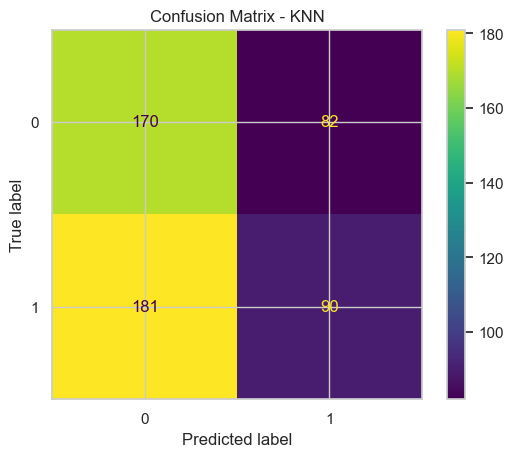

In [169]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_processed,
    y_test
)

plt.title("Confusion Matrix - KNN")
plt.show()

# 1: Final Model Train (Random Forest)

In [170]:
best_model = RandomForestClassifier(**model_param['Random Forest'])

best_model.fit(X_train_res, y_train_res)

y_pred = best_model.predict(X_test_processed)

# 2: Evaluation

In [171]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.4933078393881453

Report:
               precision    recall  f1-score   support

           0       0.48      0.69      0.57       252
           1       0.52      0.31      0.39       271

    accuracy                           0.49       523
   macro avg       0.50      0.50      0.48       523
weighted avg       0.50      0.49      0.48       523



# 3: Confusion Matrix

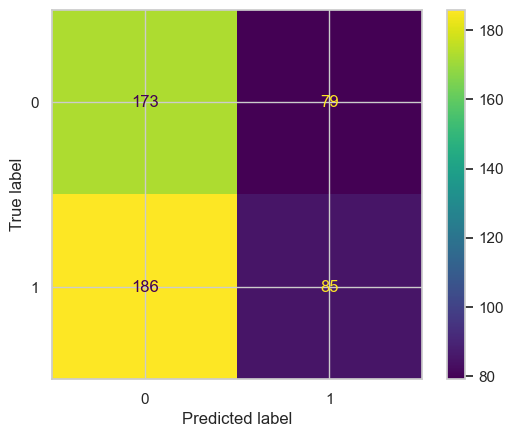

In [172]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, X_test_processed, y_test)
plt.show()